<a href="https://colab.research.google.com/github/sashkodr/Def-4-OOP/blob/main/LAB6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторна робота №6
## Робота з бібліотекою Pandas



## Крок 1. Імпорт бібліотек
Підключаємо основні бібліотеки для аналізу даних та побудови графіків.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10,5)

## Крок 2. Створення структури Series
Створюємо одновимірну структуру `Series` зі списку чисел.

In [2]:
s1 = pd.Series([10, 20, 30, 40, 50])

print(s1)

0    10
1    20
2    30
3    40
4    50
dtype: int64


## Крок 3. Створення Series з індексами
Створюємо `Series`, де кожне значення має власний символьний індекс.

In [3]:
s2 = pd.Series([10, 20, 30, 40, 50],
               ['a', 'b', 'c', 'd', 'e'])

print(s2)

a    10
b    20
c    30
d    40
e    50
dtype: int64


## Крок 4. Доступ до елементів Series
Отримуємо елемент за назвою індексу та за позицією.

In [4]:
print(s2['b'])
print(s2[2])

20
30


/tmp/ipykernel_36469/1399565111.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(s2[2])


## Крок 5. Створення DataFrame
Створюємо таблицю `DataFrame` на основі словника Python.

In [5]:
data = {
    "price": [100, 200, 300],
    "count": [5, 10, 15]
}

df = pd.DataFrame(data)

print(df)

   price  count
0    100      5
1    200     10
2    300     15


## Крок 6. DataFrame з власними індексами

In [6]:
df2 = pd.DataFrame(data,
                   index=['A', 'B', 'C'])

print(df2)

   price  count
A    100      5
B    200     10
C    300     15


## Крок 7. Вибір стовпця

In [7]:
print(df2['price'])

A    100
B    200
C    300
Name: price, dtype: int64


## Крок 8. Вибір рядка за міткою

In [8]:
print(df2.loc['A'])

price    100
count      5
Name: A, dtype: int64


## Крок 9. Вибір рядка за позицією

In [9]:
print(df2.iloc[1])

price    200
count     10
Name: B, dtype: int64


## Крок 10. Фільтрація даних
Відбираємо тільки ті рядки, де ціна більша за 150.

In [10]:
print(df2[df2['price'] > 150])

   price  count
B    200     10
C    300     15


## Крок 11. Додавання нового стовпця
Створюємо стовпець `total`, у якому зберігається загальна вартість.

In [11]:
df2['total'] = df2['price'] * df2['count']

print(df2)

   price  count  total
A    100      5    500
B    200     10   2000
C    300     15   4500


## Крок 12. Робота з пропущеними значеннями
Створюємо невелику таблицю, у якій є порожні значення.

In [12]:
from io import StringIO

data = '''price,count,percent
1,10,
2,20,51
3,30,
'''

df_nan = pd.read_csv(StringIO(data))

print(df_nan)

   price  count  percent
0      1     10      NaN
1      2     20     51.0
2      3     30      NaN


## Крок 13. Перевірка пропущених значень

In [13]:
print(df_nan.isnull())

   price  count  percent
0  False  False     True
1  False  False    False
2  False  False     True


## Крок 14. Підрахунок пропущених значень

In [14]:
print(df_nan.isnull().sum())

price      0
count      0
percent    2
dtype: int64


## Крок 15. Заповнення пропущених значень

In [15]:
print(df_nan.fillna(0))

   price  count  percent
0      1     10      0.0
1      2     20     51.0
2      3     30      0.0


## Крок 16. Видалення пропущених значень

In [16]:
print(df_nan.dropna())
print(df_nan.dropna(axis=1))

   price  count  percent
1      2     20     51.0
   price  count
0      1     10
1      2     20
2      3     30


## Крок 17. Об’єднання DataFrame
Створюємо дві таблиці та об’єднуємо їх за допомогою `pd.concat()`.

In [17]:
df1 = pd.DataFrame({
    'A': ['A0', 'A1'],
    'B': ['B0', 'B1']
})

df2 = pd.DataFrame({
    'A': ['A2', 'A3'],
    'B': ['B2', 'B3']
})

result = pd.concat([df1, df2])

print(result)

    A   B
0  A0  B0
1  A1  B1
0  A2  B2
1  A3  B3


## Крок 18. Зчитування CSV-файлу
Завантажуємо набір даних із GitHub за допомогою `pd.read_csv()`.

In [18]:
url = "https://raw.githubusercontent.com/komalaftab/Pandas_deeplearning_tutorial_for_beginners/refs/heads/master/police_project.csv"

police = pd.read_csv(url)

print(police.head())

    stop_date stop_time  county_name driver_gender  driver_age_raw  \
0  2005-01-02     01:55          NaN             M          1985.0   
1  2005-01-18     08:15          NaN             M          1965.0   
2  2005-01-23     23:15          NaN             M          1972.0   
3  2005-02-20     17:15          NaN             M          1986.0   
4  2005-03-14     10:00          NaN             F          1984.0   

   driver_age driver_race     violation_raw violation  search_conducted  \
0        20.0       White          Speeding  Speeding             False   
1        40.0       White          Speeding  Speeding             False   
2        33.0       White          Speeding  Speeding             False   
3        19.0       White  Call for Service     Other             False   
4        21.0       White          Speeding  Speeding             False   

  search_type   stop_outcome is_arrested stop_duration  drugs_related_stop  
0         NaN       Citation       False      0-15 

## Крок 19. Побудова графіка за допомогою value_counts()

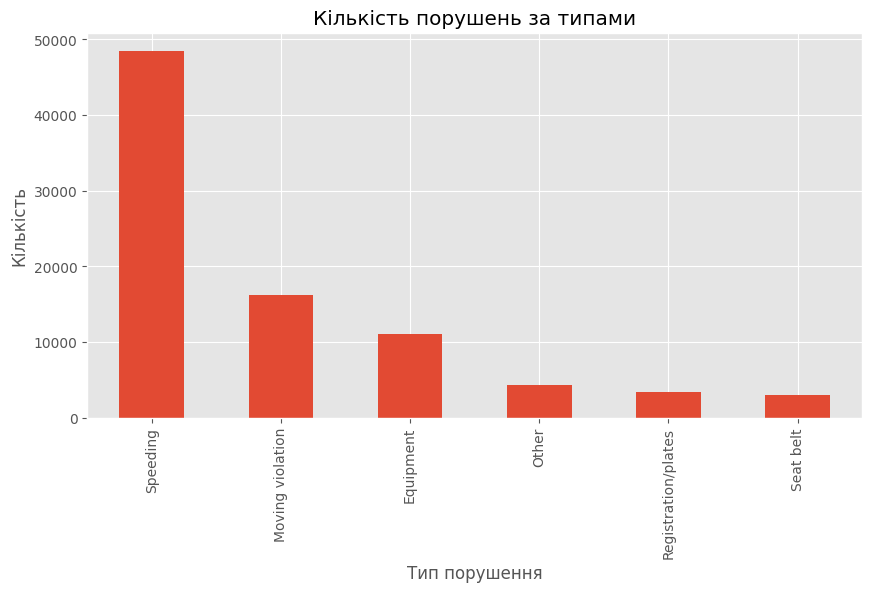

In [19]:
police['violation'].value_counts().plot(kind='bar')

plt.title("Кількість порушень за типами")
plt.xlabel("Тип порушення")
plt.ylabel("Кількість")

plt.show()

## Крок 20. Групування даних
Групуємо записи за типом порушення та визначаємо кількість записів у кожній групі.

In [20]:
violation_counts = police.groupby('violation').size()

print(violation_counts)

violation
Equipment              11020
Moving violation       16224
Other                   4317
Registration/plates     3432
Seat belt               2952
Speeding               48463
dtype: int64


## Крок 21. Побудова графіка після групування

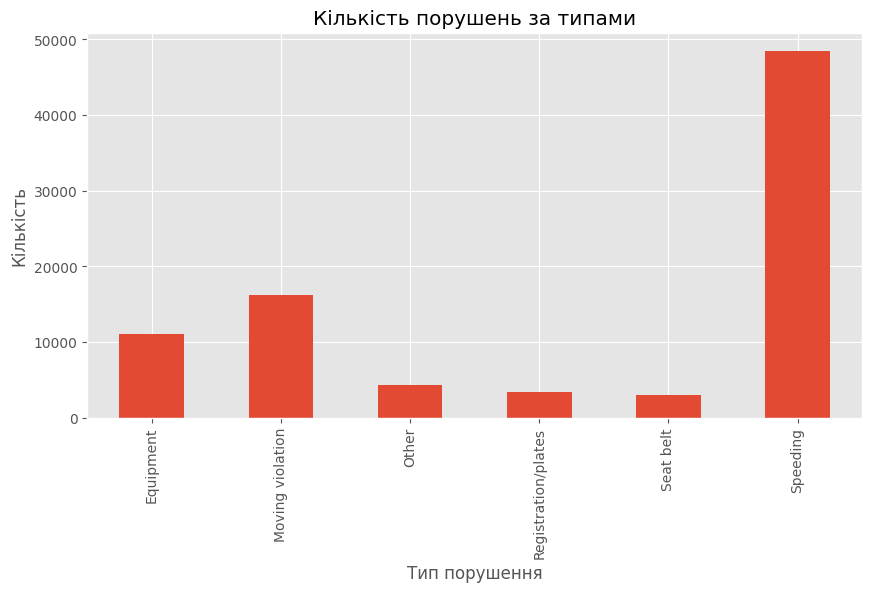

In [21]:
violation_counts.plot(kind='bar', figsize=(10,5))

plt.title("Кількість порушень за типами")
plt.xlabel("Тип порушення")
plt.ylabel("Кількість")

plt.show()

## Висновок
У лабораторній роботі було опрацьовано основні можливості бібліотеки Pandas: створення Series і DataFrame, індексацію, фільтрацію, додавання стовпців, роботу з пропущеними значеннями, об’єднання таблиць, читання CSV-файлу та групування даних. Також було побудовано графіки для візуального аналізу кількості дорожніх порушень за типами.